In [ ]:
import os
from collections import defaultdict
from pxr import Usd

# ----------------------------------------------------------
# PART 1: USD FILE PRIM CATEGORY EXTRACTION
# ----------------------------------------------------------
def extract_category_from_path(prim_path):
    parts = prim_path.strip("/").split("/")

    if "Instance" not in parts:
        return None

    idx = parts.index("Instance")
    if idx - 2 < 0:
        return None

    model_folder = parts[idx - 1]
    category_folder = parts[idx - 2]

    # Clean category: take prefix before first underscore if letters exist
    if "_" in category_folder and any(c.isalpha() for c in category_folder):
        category = category_folder.split("_")[0]
    else:
        category = category_folder

    return category, model_folder

# ----------------------------------------------------------
# PART 2: COUNT OBJECTS PER CATEGORY
# ----------------------------------------------------------
def count_objects(stage):
    category_counts = defaultdict(int)

    for prim in stage.Traverse():
        prim_path = str(prim.GetPath())

        if not prim_path.endswith("/Instance"):
            continue

        extracted = extract_category_from_path(prim_path)
        if not extracted:
            continue

        category, _ = extracted
        category_counts[category] += 1

    return dict(category_counts)

# ----------------------------------------------------------
# PART 3: SCAN ALL SCENES AND STORE DATA
# ----------------------------------------------------------
def scan_scenes(dataset_path):
    scenes_root = os.path.join(dataset_path, "scenes")
    per_scene_counts = {}  # counts per scene

    for scene_name in sorted(os.listdir(scenes_root)):
        scene_path = os.path.join(scenes_root, scene_name)
        if not os.path.isdir(scene_path):
            continue

        usd_file = os.path.join(scene_path, "start_result_navigation.usd")
        if not os.path.exists(usd_file):
            print(f"USD file not found for {scene_name}, skipping")
            continue

        stage = Usd.Stage.Open(usd_file)
        if stage is None:
            print(f"Failed to open USD file for {scene_name}, skipping")
            continue

        # Count objects
        counts = count_objects(stage)
        per_scene_counts[scene_name] = counts

    return per_scene_counts

# ----------------------------------------------------------
# PART 4: HELPER TO ACCUMULATE MULTIPLE SCENES
# ----------------------------------------------------------
def accumulate_scenes(per_scene_counts, scene_numbers):
    """
    Sum counts for multiple scenes and return one accumulated dict.
    """
    total_counts = defaultdict(int)

    for scene in scene_numbers:
        if scene not in per_scene_counts:
            print(f"Warning: {scene} not found, skipping")
            continue
        for cat, c in per_scene_counts[scene].items():
            total_counts[cat] += c

    return dict(total_counts)

# ----------------------------------------------------------
# PART 5: HELPER TO PRINT INDIVIDUAL SCENE COUNT
# ----------------------------------------------------------
def print_scene_counts(per_scene_counts, scene_name):
    """
    Print the category counts for a single scene.
    """
    if scene_name not in per_scene_counts:
        print(f"No data found for {scene_name}")
        return

    counts = per_scene_counts[scene_name]
    print(f"===== Category Counts for {scene_name} =====")
    for category, count in sorted(counts.items()):
        print(f"{category}: {count}")
    print()  # blank line for readability


In [3]:
# ----------------------------------------------------------
# MAIN
# ----------------------------------------------------------
dataset_path = "/home/junzhe_lighthouse/lighthouse/scratch/isaac_scenes_v1/grscenes_commercial"

# Scan all scenes
per_scene_counts = scan_scenes(dataset_path)

# Example: get accumulated count for multiple scenes
selected_scenes = [
    "scene1", "scene2", "scene3", "scene6", "scene7",
    "scene8", "scene9", "scene11", "scene13",
    "scene26", "scene27", "scene29"
]

accumulated = accumulate_scenes(per_scene_counts, selected_scenes)
print(f"Accumulated counts for {selected_scenes}:")
print(accumulated)

Accumulated counts for ['scene1', 'scene2', 'scene3', 'scene6', 'scene7', 'scene8', 'scene9', 'scene11', 'scene13', 'scene26', 'scene27', 'scene29']:
{'door': 15, 'window': 62, 'cabinet': 58, 'ground': 297, 'wall': 344, 'ceiling': 40, 'table': 65, 'chair': 175, 'toy': 228, 'book': 5372, 'other': 17258, 'bookshelf': 10, 'box': 245, 'pen': 521, 'curtain': 19, 'monitor': 17, 'tv': 16, 'blanket': 9, 'decoration': 47, 'plant': 56, 'picture': 29, 'person': 59, 'mouse': 15, 'stool': 15, 'keyboard': 20, 'bottle': 3304, 'shelf': 95, 'cup': 429, 'couch': 25, 'basket': 43, 'light': 23, 'shoppingtrolley': 26, 'column': 137, 'trashcan': 35, 'pillow': 32, 'bed': 5, 'toilet': 2, 'mirror': 4, 'sink': 7, 'faucet': 10, 'clothes': 41, 'tray': 124, 'counter': 23, 'lamp': 6, 'pot': 30, 'microwave': 6, 'clock': 11, 'desk': 7, 'sofa': 2, 'refrigerator': 5, 'laptop': 8, 'teatable': 2, 'bowl': 140, 'coffee': 2, 'plate': 236, 'fan': 6, 'coffeemaker': 3, 'towel': 14, 'shoe': 48, 'telephone': 4, 'electriccooker':

In [7]:
import matplotlib.pyplot as plt

def plot_category_pie(accumulated_counts, exclude_categories=None, title="Category Distribution"):
    """
    Draw a pie chart of category distribution from accumulated counts and
    print percentage of each category (text).
    
    Parameters:
        accumulated_counts (dict): {category: count}
        exclude_categories (list): categories to ignore
        title (str): title of the chart
    """
    if exclude_categories is None:
        exclude_categories = ["wall", "ground", "ceiling", "other"]

    # Filter out excluded categories
    filtered_counts = {cat: cnt for cat, cnt in accumulated_counts.items() if cat not in exclude_categories}

    if not filtered_counts:
        print("No categories to display after filtering.")
        return

    total = sum(filtered_counts.values())

    # Print percentages
    print("===== Category Percentages =====")
    for cat, cnt in sorted(filtered_counts.items()):
        pct = (cnt / total) * 100
        print(f"{cat}: {cnt} ({pct:.1f}%)")
    print()

    # Plot pie chart
    labels = list(filtered_counts.keys())
    sizes = list(filtered_counts.values())

    plt.figure(figsize=(8, 8))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
    plt.title(title)
    plt.axis('equal')  # Equal aspect ratio ensures pie is circular
    plt.show()


===== Category Percentages =====
basket: 43 (0.4%)
bed: 5 (0.0%)
blanket: 9 (0.1%)
book: 5372 (44.9%)
bookshelf: 10 (0.1%)
bottle: 3304 (27.6%)
bowl: 140 (1.2%)
box: 245 (2.0%)
cabinet: 58 (0.5%)
chair: 175 (1.5%)
clock: 11 (0.1%)
clothes: 41 (0.3%)
coffee: 2 (0.0%)
coffeemaker: 3 (0.0%)
column: 137 (1.1%)
couch: 25 (0.2%)
counter: 23 (0.2%)
cup: 429 (3.6%)
curtain: 19 (0.2%)
decoration: 47 (0.4%)
desk: 7 (0.1%)
door: 15 (0.1%)
electriccooker: 9 (0.1%)
fan: 6 (0.1%)
faucet: 10 (0.1%)
keyboard: 20 (0.2%)
lamp: 6 (0.1%)
laptop: 8 (0.1%)
light: 23 (0.2%)
microwave: 6 (0.1%)
mirror: 4 (0.0%)
monitor: 17 (0.1%)
mouse: 15 (0.1%)
nightstand: 1 (0.0%)
oven: 1 (0.0%)
pan: 10 (0.1%)
pen: 521 (4.4%)
person: 59 (0.5%)
picture: 29 (0.2%)
pillow: 32 (0.3%)
plant: 56 (0.5%)
plate: 236 (2.0%)
pot: 30 (0.3%)
refrigerator: 5 (0.0%)
shelf: 95 (0.8%)
shoe: 48 (0.4%)
shoppingtrolley: 26 (0.2%)
sink: 7 (0.1%)
sofa: 2 (0.0%)
stool: 15 (0.1%)
table: 65 (0.5%)
teatable: 2 (0.0%)
telephone: 4 (0.0%)
toilet: 2 (

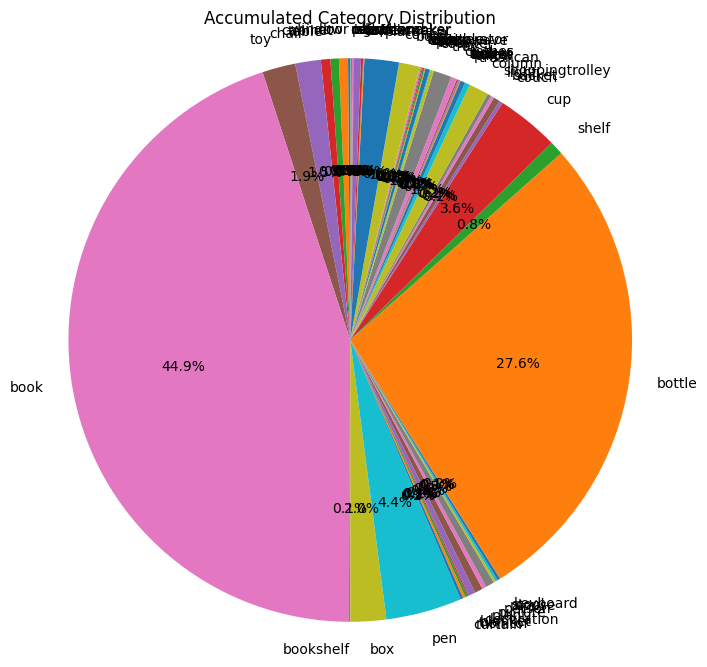

In [8]:
# Assume `accumulated` is your accumulated counts dict for selected scenes
exclude = ["wall", "ground", "ceiling", "other"]

plot_category_pie(accumulated, exclude_categories=exclude, title="Accumulated Category Distribution")
